In [1]:
import glob
import os
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
from matplotlib.animation import FuncAnimation

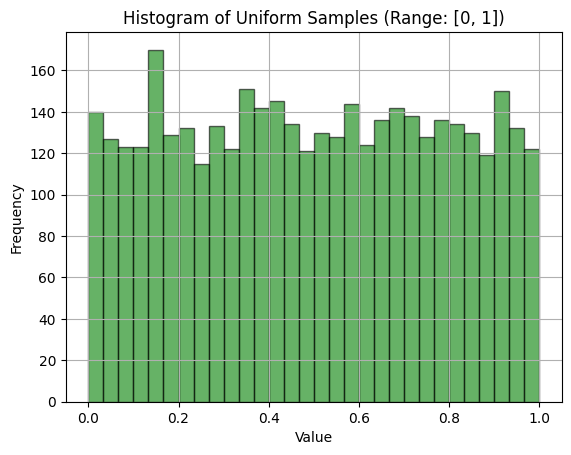

In [2]:
batch_size = 4000
# Generate sample points from a Uniform distribution (range: [low, high])
uniform_samples = np.random.uniform(low=0, high=1, size=batch_size).astype(np.float32)
uniform_samples = torch.tensor(uniform_samples).numpy()

# Plot Histogram
plt.hist(uniform_samples, bins=30, alpha=0.6, color='green', edgecolor='black')
plt.title('Histogram of Uniform Samples (Range: [0, 1])')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

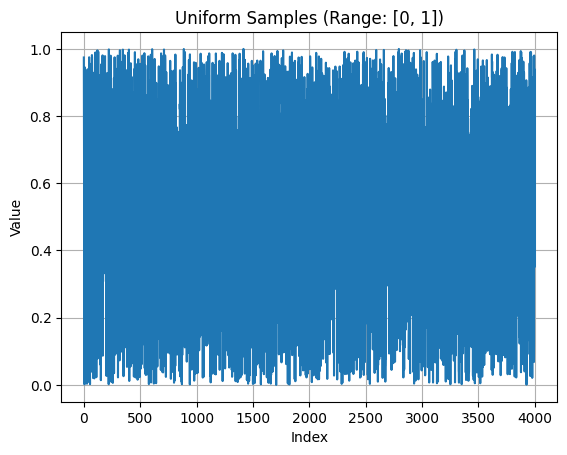

In [3]:
plt.plot(uniform_samples)
plt.title('Uniform Samples (Range: [0, 1])')
plt.xlabel('Index')
plt.ylabel('Value')
plt.grid(True)
plt.show()

Text(0.5, 0, 'Value')

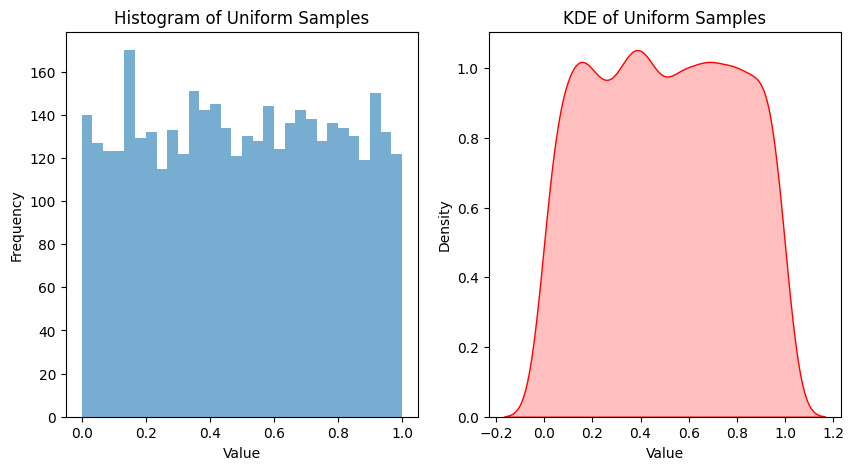

In [4]:
# Plot Histogram
plt.figure(figsize=(10, 5))

# Subplot 1: Histogram
plt.subplot(1, 2, 1)
plt.hist(uniform_samples, bins=30, alpha=0.6)
plt.title('Histogram of Uniform Samples')
plt.xlabel('Value')
plt.ylabel('Frequency')

# Subplot 2: Kernel Density Estimate (KDE)
plt.subplot(1, 2, 2)
sns.kdeplot(uniform_samples, color='red', fill=True)
plt.title('KDE of Uniform Samples')
plt.xlabel('Value')

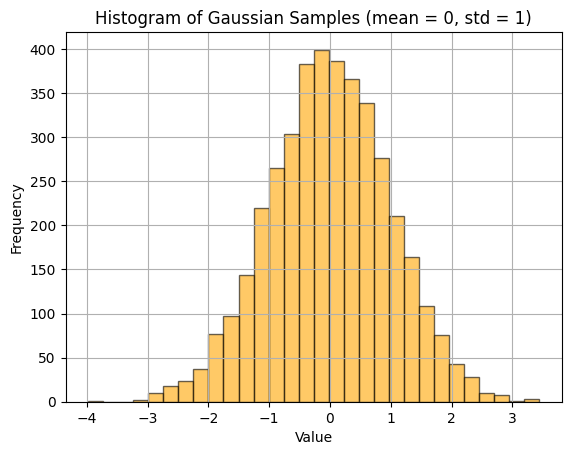

In [5]:
# Step 2: Generate 400 sample points from a Gaussian distribution (mean=0, std=1)
# gaussian_samples = np.random.normal(loc=0, scale=1, size=400).astype(np.float32)
gaussian_samples = norm.ppf(uniform_samples)
gaussian_samples = torch.tensor(gaussian_samples).numpy()

# Plot Histogram
plt.hist(gaussian_samples, bins=30, alpha=0.6, color='orange', edgecolor='black')
plt.title('Histogram of Gaussian Samples (mean = 0, std = 1)')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

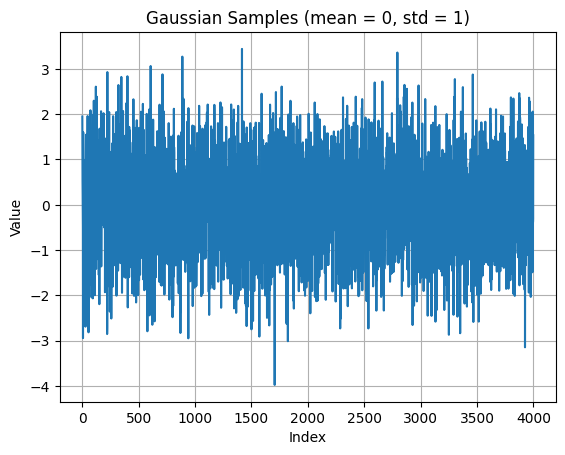

In [6]:
plt.plot(gaussian_samples)
plt.title('Gaussian Samples (mean = 0, std = 1)')
plt.xlabel('Index')
plt.ylabel('Value')
plt.grid(True)
plt.show()

Text(0.5, 0, 'Value')

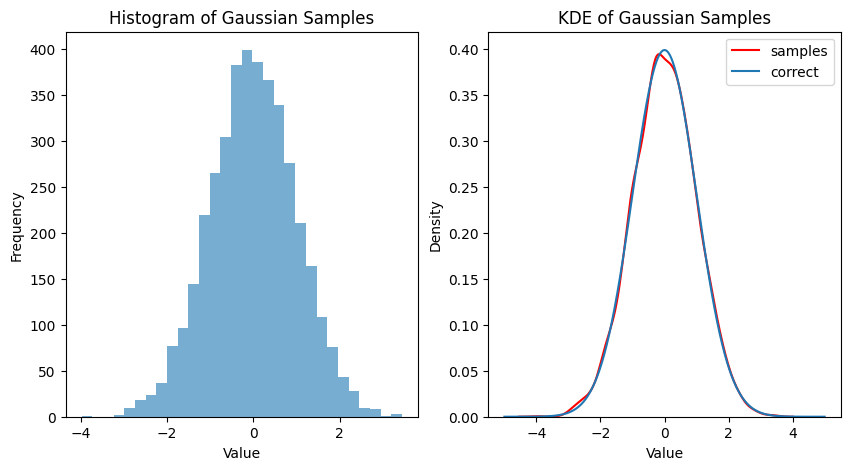

In [7]:
# Plot Histogram
plt.figure(figsize=(10, 5))

# Subplot 1: Histogram
plt.subplot(1, 2, 1)
plt.hist(gaussian_samples, bins=30, alpha=0.6)
plt.title('Histogram of Gaussian Samples')
plt.xlabel('Value')
plt.ylabel('Frequency')

# Subplot 2: Kernel Density Estimate (KDE)
plt.subplot(1, 2, 2)
sns.kdeplot(gaussian_samples, color='red',label='samples')
# Mean = 0, SD = 1.
x_axis = np.arange(-5, 5, 0.0005)
plt.plot(x_axis, norm.pdf(x_axis,0,1), label = 'correct')
plt.legend()
plt.title('KDE of Gaussian Samples')
plt.xlabel('Value')

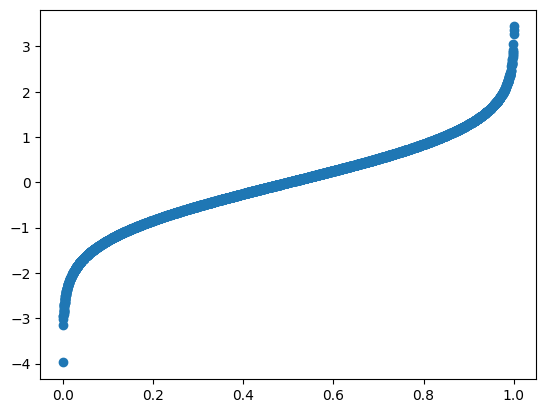

In [8]:
plt.scatter(uniform_samples, gaussian_samples)

In [9]:
uniform_samples = torch.tensor(uniform_samples).unsqueeze(1)
gaussian_samples = torch.tensor(gaussian_samples).unsqueeze(1)

In [10]:
class FNN(nn.Module):
    def __init__(self):
        super(FNN, self).__init__()
        self.fc1 = nn.Linear(1, 128)
        self.fc2 = nn.Linear(128, 128)
        self.fc3 = nn.Linear(128, 128)
        self.fc4 = nn.Linear(128, 128)
        self.fc5 = nn.Linear(128, 128)
        self.fc6 = nn.Linear(128, 1)
        self.tanh = nn.Tanh()

    def forward(self, x):
        x = self.tanh(self.fc1(x))
        x = self.tanh(self.fc2(x))
        x = self.tanh(self.fc3(x))
        x = self.tanh(self.fc4(x))
        x = self.tanh(self.fc5(x))
        return self.fc6(x)

In [11]:
# Function to compute moments (mean, variance, skewness, kurtosis, and 5th moment)
def compute_moments(samples):
    mean = torch.mean(samples)
    variance = torch.var(samples, unbiased=False)  # Population variance
    skewness = torch.mean(((samples - mean) ** 3)) / (variance ** 1.5)
    kurtosis = torch.mean(((samples - mean) ** 4)) / (variance ** 2) - 3
    fifth_moment = torch.mean((samples - mean) ** 5)
    return mean, variance, skewness, kurtosis, fifth_moment

In [12]:
def compute_mean(samples):
    mean = torch.mean(samples)
    return mean

In [13]:
def compute_variance(samples):
    variance = torch.var(samples, unbiased=False)
    return variance

In [14]:
def compute_skewness(samples):
    mean = compute_mean(samples)
    variance = compute_variance(samples)
    skewness = torch.mean(((samples - mean) ** 3)) / (variance ** 1.5)
    return skewness

In [15]:
def compute_kurtosis(samples):
    mean = compute_mean(samples)
    variance = compute_variance(samples)
    kurtosis = torch.mean(((samples - mean) ** 4)) / (variance ** 2) - 3
    return kurtosis

In [16]:
# Initialize the neural network
model = FNN()

In [17]:
# Define optimizer
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Initialize lists to store each moment loss over epochs
mean_loss_list = []
variance_loss_list = []
skewness_loss_list = []
kurtosis_loss_list = []
total_loss_list = []
epoch_list = []

# Training loop
num_epochs = 10000
save_interval = 10  # Save model every 10 iterations

for epoch in range(num_epochs):
    uni_input = np.random.uniform(low=0, high=1, size=batch_size).astype(np.float32)
    uni_input = torch.tensor(uniform_samples).unsqueeze(1)
    # Forward pass
    outputs = model(uni_input)
    
    # Compute individual moment losses
    mean_loss = torch.abs(compute_mean(outputs) - 0)
    variance_loss = torch.abs(compute_variance(outputs) - 1) 
    skewness_loss = torch.abs(compute_skewness(outputs) - 0)
    kurtosis_loss = torch.abs(compute_kurtosis(outputs) - 3)

    # Total loss with weighted moments
    total_loss = (5*mean_loss + 10*variance_loss + skewness_loss + kurtosis_loss)

    # Backward pass and optimization
    optimizer.zero_grad()
    total_loss.backward()
    optimizer.step()
    
    # Store each moment loss and epoch number
    mean_loss_list.append(mean_loss.item())
    variance_loss_list.append(variance_loss.item())
    skewness_loss_list.append(skewness_loss.item())
    kurtosis_loss_list.append(kurtosis_loss.item())
    total_loss_list.append(total_loss.item())
    epoch_list.append(epoch + 1)
    
    print(f'Epoch [{epoch+1}/{num_epochs}], Mean Loss: {mean_loss.item():.5f}, '
          f'Variance Loss: {variance_loss.item():.5f}, Skewness Loss: {skewness_loss.item():.6f}, '
          f'Kurtosis Loss: {kurtosis_loss.item():.6f}')
    
    # Save model every 10 iterations
    if (epoch + 1) % save_interval == 0:
        torch.save(model.state_dict(), f"model_epoch_{epoch+1}.pt")
        print(f"Model saved at epoch {epoch+1}")
        
    # Early stopping condition
    if (mean_loss <= 0.001 and variance_loss <= 0.001 and skewness_loss <= 0.01 and 
        kurtosis_loss <= 0.01):
        print(f"Early stopping at epoch {epoch + 1}")
        torch.save(model.state_dict(), f"model_epoch_{epoch+1}.pt")
        break


/tmp/ipykernel_635995/2552445540.py:18: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  uni_input = torch.tensor(uniform_samples).unsqueeze(1)


Epoch [1/10000], Mean Loss: 0.01216, Variance Loss: 1.00000, Skewness Loss: 0.905720, Kurtosis Loss: 3.542148
Epoch [2/10000], Mean Loss: 0.03466, Variance Loss: 0.99814, Skewness Loss: 0.069734, Kurtosis Loss: 4.214607
Epoch [3/10000], Mean Loss: 0.02941, Variance Loss: 0.99474, Skewness Loss: 0.046605, Kurtosis Loss: 4.220164
Epoch [4/10000], Mean Loss: 0.00717, Variance Loss: 0.99090, Skewness Loss: 0.024075, Kurtosis Loss: 4.224792
Epoch [5/10000], Mean Loss: 0.01386, Variance Loss: 0.98696, Skewness Loss: 0.018984, Kurtosis Loss: 4.227423
Epoch [6/10000], Mean Loss: 0.00698, Variance Loss: 0.98294, Skewness Loss: 0.025635, Kurtosis Loss: 4.229113
Epoch [7/10000], Mean Loss: 0.00505, Variance Loss: 0.97875, Skewness Loss: 0.019395, Kurtosis Loss: 4.231826
Epoch [8/10000], Mean Loss: 0.01109, Variance Loss: 0.97427, Skewness Loss: 0.024170, Kurtosis Loss: 4.233631
Epoch [9/10000], Mean Loss: 0.00545, Variance Loss: 0.96943, Skewness Loss: 0.016660, Kurtosis Loss: 4.236347
Epoch [10/

Epoch [77/10000], Mean Loss: 0.00505, Variance Loss: 0.01974, Skewness Loss: 0.001142, Kurtosis Loss: 4.336532
Epoch [78/10000], Mean Loss: 0.02955, Variance Loss: 0.05957, Skewness Loss: 0.011181, Kurtosis Loss: 4.341166
Epoch [79/10000], Mean Loss: 0.01342, Variance Loss: 0.07199, Skewness Loss: 0.005633, Kurtosis Loss: 4.342093
Epoch [80/10000], Mean Loss: 0.04846, Variance Loss: 0.02122, Skewness Loss: 0.016061, Kurtosis Loss: 4.338962
Model saved at epoch 80
Epoch [81/10000], Mean Loss: 0.05845, Variance Loss: 0.07637, Skewness Loss: 0.019638, Kurtosis Loss: 4.332856
Epoch [82/10000], Mean Loss: 0.02158, Variance Loss: 0.11156, Skewness Loss: 0.006574, Kurtosis Loss: 4.331001
Epoch [83/10000], Mean Loss: 0.05518, Variance Loss: 0.09913, Skewness Loss: 0.020699, Kurtosis Loss: 4.331250
Epoch [84/10000], Mean Loss: 0.08122, Variance Loss: 0.04158, Skewness Loss: 0.029973, Kurtosis Loss: 4.334345
Epoch [85/10000], Mean Loss: 0.05913, Variance Loss: 0.06724, Skewness Loss: 0.022144, K

Epoch [154/10000], Mean Loss: 0.00910, Variance Loss: 0.05858, Skewness Loss: 0.003776, Kurtosis Loss: 4.343786
Epoch [155/10000], Mean Loss: 0.06410, Variance Loss: 0.07635, Skewness Loss: 0.022986, Kurtosis Loss: 4.344249
Epoch [156/10000], Mean Loss: 0.08811, Variance Loss: 0.03257, Skewness Loss: 0.031956, Kurtosis Loss: 4.341065
Epoch [157/10000], Mean Loss: 0.07011, Variance Loss: 0.05775, Skewness Loss: 0.025685, Kurtosis Loss: 4.335937
Epoch [158/10000], Mean Loss: 0.01751, Variance Loss: 0.08991, Skewness Loss: 0.006645, Kurtosis Loss: 4.334737
Epoch [159/10000], Mean Loss: 0.06539, Variance Loss: 0.07734, Skewness Loss: 0.023457, Kurtosis Loss: 4.335136
Epoch [160/10000], Mean Loss: 0.10070, Variance Loss: 0.01944, Skewness Loss: 0.036061, Kurtosis Loss: 4.338068
Model saved at epoch 160
Epoch [161/10000], Mean Loss: 0.09036, Variance Loss: 0.09062, Skewness Loss: 0.031936, Kurtosis Loss: 4.345216
Epoch [162/10000], Mean Loss: 0.04317, Variance Loss: 0.13589, Skewness Loss: 0

Epoch [233/10000], Mean Loss: 0.06803, Variance Loss: 0.02662, Skewness Loss: 0.024561, Kurtosis Loss: 4.344194
Epoch [234/10000], Mean Loss: 0.02157, Variance Loss: 0.03002, Skewness Loss: 0.007298, Kurtosis Loss: 4.341125
Epoch [235/10000], Mean Loss: 0.05614, Variance Loss: 0.03386, Skewness Loss: 0.021848, Kurtosis Loss: 4.340228
Epoch [236/10000], Mean Loss: 0.09127, Variance Loss: 0.00859, Skewness Loss: 0.035002, Kurtosis Loss: 4.342016
Epoch [237/10000], Mean Loss: 0.08813, Variance Loss: 0.00330, Skewness Loss: 0.033857, Kurtosis Loss: 4.341342
Epoch [238/10000], Mean Loss: 0.04879, Variance Loss: 0.03585, Skewness Loss: 0.019075, Kurtosis Loss: 4.344812
Epoch [239/10000], Mean Loss: 0.02324, Variance Loss: 0.01683, Skewness Loss: 0.007907, Kurtosis Loss: 4.344074
Epoch [240/10000], Mean Loss: 0.05256, Variance Loss: 0.05050, Skewness Loss: 0.019023, Kurtosis Loss: 4.339416
Model saved at epoch 240
Epoch [241/10000], Mean Loss: 0.04176, Variance Loss: 0.06287, Skewness Loss: 0

...

Epoch [7313/10000], Mean Loss: 0.01239, Variance Loss: 0.00267, Skewness Loss: 0.006203, Kurtosis Loss: 0.016241
Epoch [7314/10000], Mean Loss: 0.04103, Variance Loss: 0.00659, Skewness Loss: 0.064625, Kurtosis Loss: 0.019903
Epoch [7315/10000], Mean Loss: 0.06561, Variance Loss: 0.02055, Skewness Loss: 0.086307, Kurtosis Loss: 0.020968
Epoch [7316/10000], Mean Loss: 0.05568, Variance Loss: 0.01123, Skewness Loss: 0.066739, Kurtosis Loss: 0.004941
Epoch [7317/10000], Mean Loss: 0.01528, Variance Loss: 0.03180, Skewness Loss: 0.011159, Kurtosis Loss: 0.061824
Epoch [7318/10000], Mean Loss: 0.04373, Variance Loss: 0.03927, Skewness Loss: 0.067738, Kurtosis Loss: 0.072942
Epoch [7319/10000], Mean Loss: 0.06571, Variance Loss: 0.00995, Skewness Loss: 0.101508, Kurtosis Loss: 0.029857
Epoch [7320/10000], Mean Loss: 0.05525, Variance Loss: 0.04985, Skewness Loss: 0.095601, Kurtosis Loss: 0.056468
Model saved at epoch 7320
Epoch [7321/10000], Mean Loss: 0.02268, Variance Loss: 0.07394, Skewne

Epoch [7391/10000], Mean Loss: 0.00620, Variance Loss: 0.02918, Skewness Loss: 0.007493, Kurtosis Loss: 0.037231
Epoch [7392/10000], Mean Loss: 0.02974, Variance Loss: 0.02575, Skewness Loss: 0.023350, Kurtosis Loss: 0.026267
Epoch [7393/10000], Mean Loss: 0.03202, Variance Loss: 0.01046, Skewness Loss: 0.001853, Kurtosis Loss: 0.032889
Epoch [7394/10000], Mean Loss: 0.01151, Variance Loss: 0.01282, Skewness Loss: 0.047136, Kurtosis Loss: 0.041807
Epoch [7395/10000], Mean Loss: 0.02200, Variance Loss: 0.01600, Skewness Loss: 0.092449, Kurtosis Loss: 0.002969
Epoch [7396/10000], Mean Loss: 0.02920, Variance Loss: 0.01956, Skewness Loss: 0.105067, Kurtosis Loss: 0.004939
Epoch [7397/10000], Mean Loss: 0.01307, Variance Loss: 0.00680, Skewness Loss: 0.086033, Kurtosis Loss: 0.035284
Epoch [7398/10000], Mean Loss: 0.03052, Variance Loss: 0.00356, Skewness Loss: 0.034406, Kurtosis Loss: 0.022338
Epoch [7399/10000], Mean Loss: 0.04835, Variance Loss: 0.01307, Skewness Loss: 0.005629, Kurtosi

Epoch [7468/10000], Mean Loss: 0.01282, Variance Loss: 0.01094, Skewness Loss: 0.021957, Kurtosis Loss: 0.020599
Epoch [7469/10000], Mean Loss: 0.01942, Variance Loss: 0.02128, Skewness Loss: 0.024911, Kurtosis Loss: 0.021395
Epoch [7470/10000], Mean Loss: 0.00977, Variance Loss: 0.01876, Skewness Loss: 0.029144, Kurtosis Loss: 0.014006
Model saved at epoch 7470
Epoch [7471/10000], Mean Loss: 0.01479, Variance Loss: 0.01496, Skewness Loss: 0.034470, Kurtosis Loss: 0.037497
Epoch [7472/10000], Mean Loss: 0.01299, Variance Loss: 0.01527, Skewness Loss: 0.007147, Kurtosis Loss: 0.037909
Epoch [7473/10000], Mean Loss: 0.01254, Variance Loss: 0.01463, Skewness Loss: 0.048705, Kurtosis Loss: 0.005124
Epoch [7474/10000], Mean Loss: 0.01184, Variance Loss: 0.01089, Skewness Loss: 0.067482, Kurtosis Loss: 0.000423
Epoch [7475/10000], Mean Loss: 0.01379, Variance Loss: 0.01556, Skewness Loss: 0.053247, Kurtosis Loss: 0.030777
Epoch [7476/10000], Mean Loss: 0.02082, Variance Loss: 0.00881, Skewne

Epoch [7545/10000], Mean Loss: 0.03023, Variance Loss: 0.07403, Skewness Loss: 0.055631, Kurtosis Loss: 0.105000
Epoch [7546/10000], Mean Loss: 0.01070, Variance Loss: 0.11842, Skewness Loss: 0.035972, Kurtosis Loss: 0.166744
Epoch [7547/10000], Mean Loss: 0.02967, Variance Loss: 0.12343, Skewness Loss: 0.010087, Kurtosis Loss: 0.175830
Epoch [7548/10000], Mean Loss: 0.03520, Variance Loss: 0.08853, Skewness Loss: 0.015882, Kurtosis Loss: 0.133425
Epoch [7549/10000], Mean Loss: 0.00996, Variance Loss: 0.02119, Skewness Loss: 0.014643, Kurtosis Loss: 0.046750
Epoch [7550/10000], Mean Loss: 0.03504, Variance Loss: 0.06896, Skewness Loss: 0.049365, Kurtosis Loss: 0.080033
Model saved at epoch 7550
Epoch [7551/10000], Mean Loss: 0.04489, Variance Loss: 0.11551, Skewness Loss: 0.042278, Kurtosis Loss: 0.147477
Epoch [7552/10000], Mean Loss: 0.02377, Variance Loss: 0.12734, Skewness Loss: 0.002072, Kurtosis Loss: 0.163905
Epoch [7553/10000], Mean Loss: 0.01704, Variance Loss: 0.10958, Skewne

Epoch [7623/10000], Mean Loss: 0.09040, Variance Loss: 0.03127, Skewness Loss: 0.075414, Kurtosis Loss: 0.006847
Epoch [7624/10000], Mean Loss: 0.02515, Variance Loss: 0.02809, Skewness Loss: 0.007789, Kurtosis Loss: 0.074095
Epoch [7625/10000], Mean Loss: 0.06302, Variance Loss: 0.03747, Skewness Loss: 0.099616, Kurtosis Loss: 0.078669
Epoch [7626/10000], Mean Loss: 0.10162, Variance Loss: 0.00818, Skewness Loss: 0.137873, Kurtosis Loss: 0.031878
Epoch [7627/10000], Mean Loss: 0.09552, Variance Loss: 0.05391, Skewness Loss: 0.128118, Kurtosis Loss: 0.052655
Epoch [7628/10000], Mean Loss: 0.03291, Variance Loss: 0.07081, Skewness Loss: 0.059860, Kurtosis Loss: 0.073871
Epoch [7629/10000], Mean Loss: 0.08332, Variance Loss: 0.04866, Skewness Loss: 0.063432, Kurtosis Loss: 0.054462
Epoch [7630/10000], Mean Loss: 0.11446, Variance Loss: 0.01562, Skewness Loss: 0.109540, Kurtosis Loss: 0.023275
Model saved at epoch 7630
Epoch [7631/10000], Mean Loss: 0.07197, Variance Loss: 0.03402, Skewne

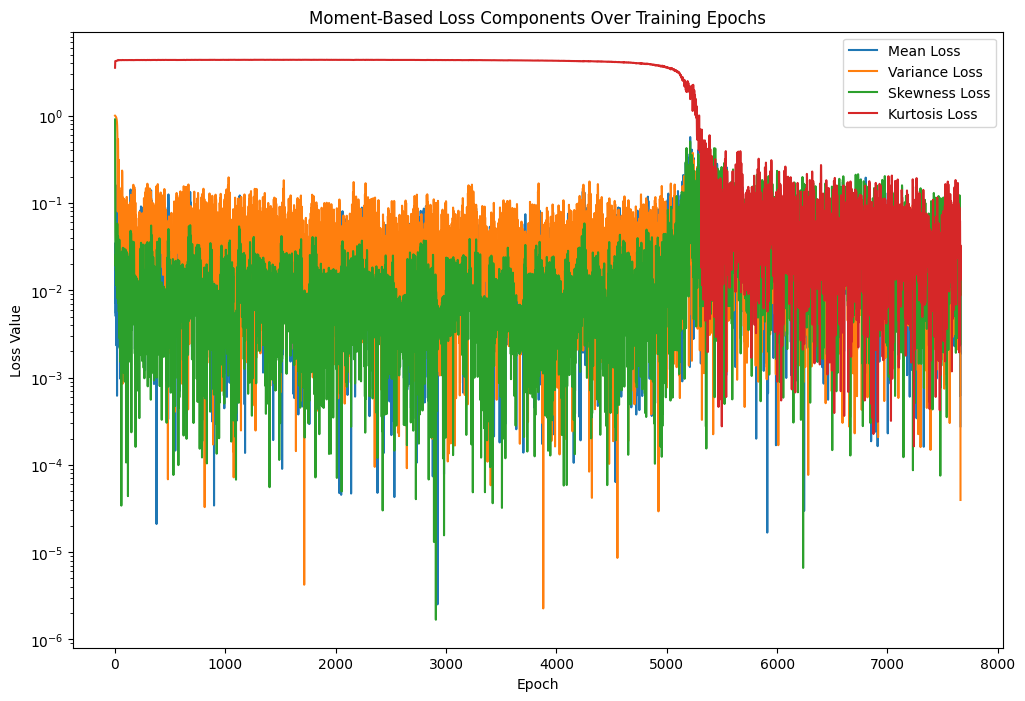

In [18]:
# Plot each loss component
plt.figure(figsize=(12, 8))
plt.yscale('log')
plt.plot(epoch_list, mean_loss_list, label="Mean Loss")
plt.plot(epoch_list, variance_loss_list, label="Variance Loss")
plt.plot(epoch_list, skewness_loss_list, label="Skewness Loss")
plt.plot(epoch_list, kurtosis_loss_list, label="Kurtosis Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss Value")
plt.title("Moment-Based Loss Components Over Training Epochs")
plt.legend()
plt.show()

Text(0, 0.5, '$l_2$')

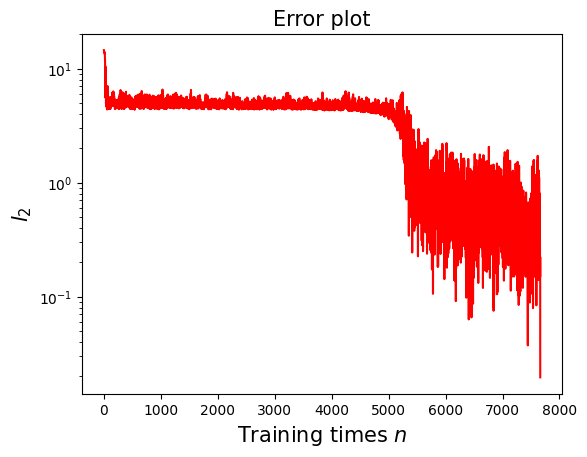

In [19]:
fig = plt.figure(1)
ax = fig.add_axes([0.15, 0.15, 0.75, 0.75])
plt.title("Error plot",fontsize=15) 
plt.yscale('log')
plt.plot(epoch_list, total_loss_list,'r',label='Training error')
plt.xlabel(r'Training times $n$',fontsize=15)
plt.ylabel(r'$l_2$',fontsize=15)

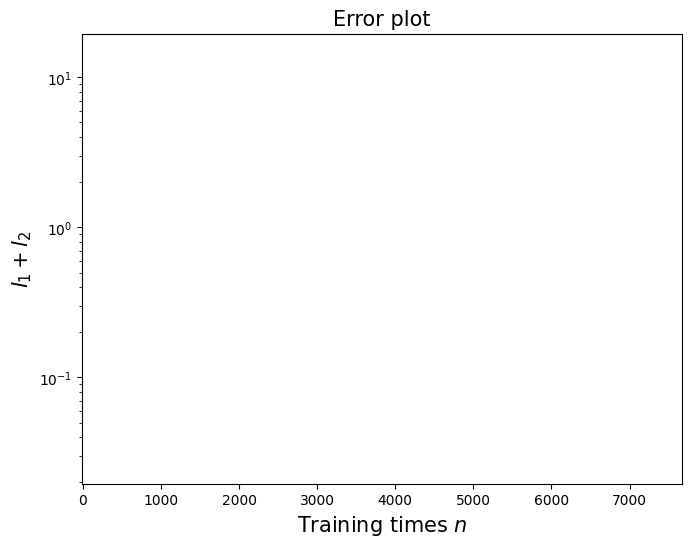

In [20]:
# Initialize figure
fig = plt.figure(1, figsize=(8, 6))
ax = fig.add_axes([0.15, 0.15, 0.75, 0.75])
ax.set_title("Error plot", fontsize=15)
ax.set_xlabel(r'Training times $n$', fontsize=15)
ax.set_ylabel(r'$l_1+l_2$', fontsize=15)
ax.set_yscale('log')  # Use logarithmic scale for better visualization
ax.set_xlim(-10, epoch_list[-1]+10)  # Initial x-axis limit
ax.set_ylim(min(total_loss_list)-0.00001, max(total_loss_list)+5)  # Set y-axis limit

# Initialize line plot object (empty initially)
line, = ax.plot([], [], 'r', label='Training error')

# Function to update the plot in the animation
def update_plot(frame):
    # Show 10 more points at each frame
    end_index = (frame + 1) * 10
    epoch_data = epoch_list[:end_index]
    loss_data = total_loss_list[:end_index]
    
    # Update the line data
    line.set_data(epoch_data, loss_data)
    
    # Update the title to reflect the current epoch range
    ax.set_title(f"Error plot from Epoch 1 to Epoch {epoch_data[-1]}", fontsize=15)
    
    return line,

# Number of frames to show (every 10 epochs)
num_frames = len(epoch_list) // 10  # Adjust for how many epochs you have
if len(epoch_list) % 10 != 0:
    num_frames += 1

# Create the animation
anim = FuncAnimation(fig, update_plot, frames=num_frames, interval=500, repeat=False)

# Show the animation
plt.show()

# Optionally save the animation as a GIF
anim.save("error_plot_animation.gif", writer="pillow", fps=2)


In [21]:
from matplotlib.animation import FuncAnimation

# Set the input for testing the transformation
input_test = torch.tensor(np.linspace(0, 1, batch_size).astype(np.float32)).unsqueeze(1)
uniform_samples_np = uniform_samples.numpy()
gaussian_samples_np = gaussian_samples.numpy()

In [22]:
# Function to load model and transform samples
def load_and_transform(model, model_path, input_test):
    model.load_state_dict(torch.load(model_path))
    model.eval()  # Set model to evaluation mode
    with torch.no_grad():
        transformed_samples = model(input_test)
    return transformed_samples.numpy()

In [23]:
# Get list of saved models sorted by creation time
model_files = sorted(glob.glob("model_epoch_*.pt"), key=os.path.getmtime)

if not model_files:
    print("No model files found.")
else:
    # Collect transformed samples for each saved model
    transformed_samples_list = [load_and_transform(model, path, input_test) for path in model_files]

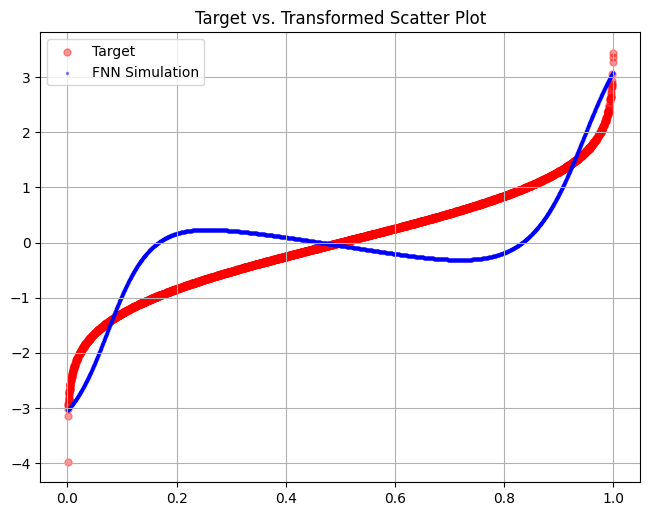

In [24]:
# Set up the figure with two subplots
fig = plt.figure(1, figsize=(8, 6))
ax = fig.add_axes([0.15, 0.15, 0.75, 0.75])

# Scatter plot
scatter_target = ax.scatter(uniform_samples_np, gaussian_samples_np, c='r', s=25, alpha=0.4, marker='o', label='Target')
scatter_sim = ax.scatter(1-input_test.numpy(), transformed_samples_list[-1], c='b', s=10, alpha=0.4, marker='.', label='FNN Simulation')
ax.legend()
ax.set_title("Target vs. Transformed Scatter Plot")
ax.grid(True)


In [25]:
# Animation function
def animate(i):
    # Update scatter plot for FNN simulation
    epoch = int(model_files[i].split('_')[-1].split('.')[0])
    scatter_sim.set_offsets(np.c_[1-input_test.numpy(), transformed_samples_list[i]])
    ax.set_title(f"Scatter Plot at Epoch {epoch}")

In [26]:
# Create the animation
anim = FuncAnimation(fig, animate, frames=len(transformed_samples_list), interval=50)
%matplotlib inline
# Display the animation
plt.show()
# Save animation
anim.save("training_animation.gif", writer="pillow", fps=20)

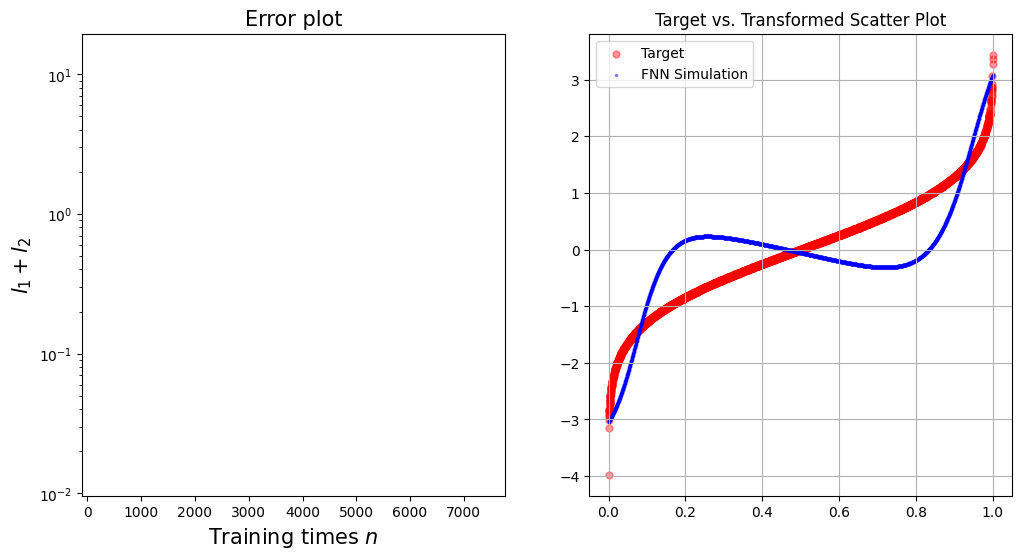

In [27]:
# Set up the figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# Total loss plot (ax1)
ax1.set_title("Error plot", fontsize=15)
ax1.set_xlabel(r'Training times $n$', fontsize=15)
ax1.set_ylabel(r'$l_1+l_2$', fontsize=15)
ax1.set_yscale('log')  # Use logarithmic scale for better visualization
ax1.set_xlim(-100, epoch_list[-1]+100)  # Initial x-axis limit
ax1.set_ylim(min(total_loss_list)-0.01, max(total_loss_list)+5)  # Set y-axis limit
line, = ax1.plot([], [], 'r', label='Training error')

# Scatter plot (ax2)
scatter_target = ax2.scatter(uniform_samples_np, gaussian_samples_np, c='r', s=25, alpha=0.4, marker='o', label='Target')
scatter_sim = ax2.scatter(1-input_test.numpy(), transformed_samples_list[-1], c='b', s=10, alpha=0.4, marker='.', label='FNN Simulation')
ax2.legend()
ax2.set_title("Target vs. Transformed Scatter Plot")
ax2.grid(True)

# Function to update both the total loss plot and scatter plot
def update_plot(frame):
    # Update total loss plot (ax1)
    end_index = (frame + 1) * 10
    epoch_data = epoch_list[:end_index]
    loss_data = total_loss_list[:end_index]
    line.set_data(epoch_data, loss_data)
    
    # Update scatter plot (ax2) for FNN simulation
    scatter_sim.set_offsets(np.c_[1-input_test.numpy(), transformed_samples_list[frame]])
    
    # Update titles
    ax1.set_title(f"Error plot from Epoch 1 to Epoch {epoch_data[-1]}", fontsize=15)
    ax2.set_title(f"Scatter Plot at Epoch {frame * 10}", fontsize=15)
    
    return line, scatter_sim  # Return the updated plot elements

# Number of frames to show (every 10 epochs)
num_frames = len(epoch_list) // 10  # Adjust for how many epochs you have
if len(epoch_list) % 10 != 0:
    num_frames += 1

# Create the combined animation
anim = FuncAnimation(fig, update_plot, frames=num_frames, interval=50, repeat=False)

# Show the animation
plt.show()

# Optionally, save the animation as a GIF
anim.save("combined_training_animation.gif", writer="pillow", fps=20)

In [28]:
# Test the transformation from final model
with torch.no_grad():
    transformed_samples = model(input_test)


# Convert tensors to numpy for visualization
transformed_samples_np = transformed_samples.numpy()

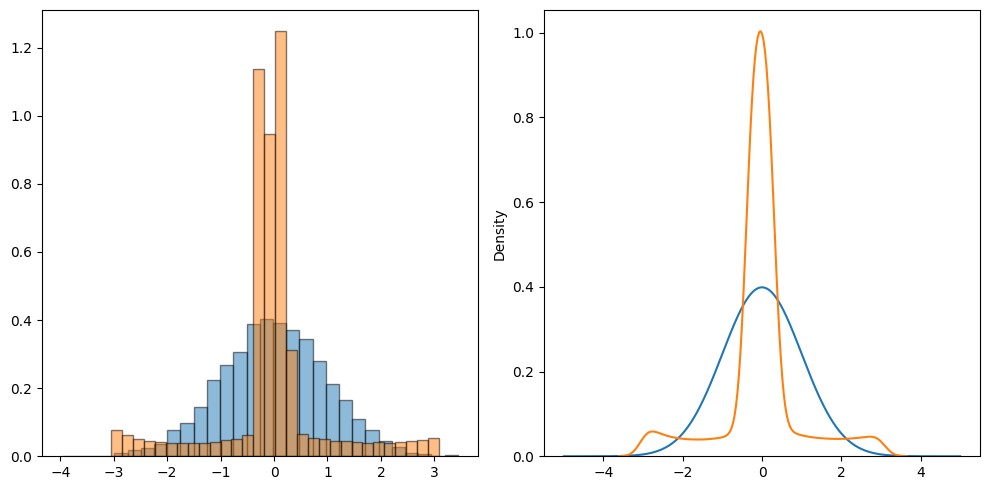

In [29]:
# Step 7: Plot the original and transformed distributions
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.hist(gaussian_samples_np, bins=30, alpha=0.5, density=True, edgecolor='black')
plt.hist(transformed_samples_np, bins=30, alpha=0.5, density=True, edgecolor='black')
# plt.title('Gaussian vs Transformed Distribution')
# plt.legend()

plt.subplot(1, 2, 2)
# Gaussian distribution with Mean = 0, SD = 1.
x_axis = np.arange(-5, 5, 0.0005)
plt.plot(x_axis, norm.pdf(x_axis,0,1))
sns.kdeplot(transformed_samples.cpu().reshape(batch_size))
# plt.title('Gaussian vs Transformed Distribution')

plt.tight_layout()
plt.show()

Text(0, 0.5, 'Frequency')

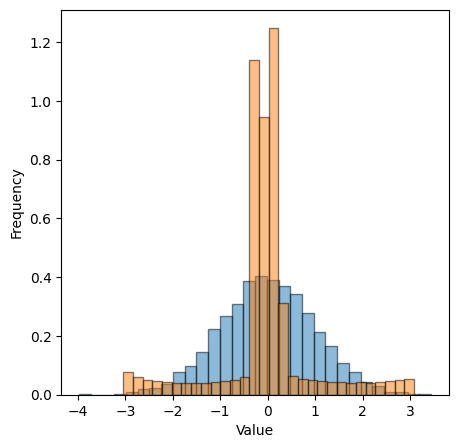

In [30]:
plt.figure(figsize=(5, 5))
plt.hist(gaussian_samples_np, bins=30, alpha=0.5, density=True, edgecolor='black')
plt.hist(transformed_samples_np, bins=30, alpha=0.5, density=True, edgecolor='black')
plt.xlabel('Value')
plt.ylabel('Frequency')
# plt.title('Gaussian vs Transformed Distribution')

Text(0.5, 0, 'Value')

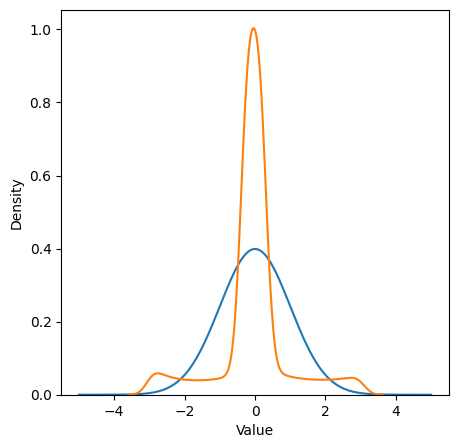

In [31]:
plt.figure(figsize=(5, 5))
# Normal distribution with Mean = 0, SD = 1.
x_axis = np.arange(-5, 5, 0.0005)
plt.plot(x_axis, norm.pdf(x_axis,0,1))
sns.kdeplot(transformed_samples.cpu().reshape(batch_size))
# plt.title('Gaussian vs Transformed Distribution')
plt.xlabel('Value')

In [32]:
# Test the transformation from final model
with torch.no_grad():
    transformed_samples1 = model(uniform_samples)


print(compute_mean(transformed_samples1))
print(compute_variance(transformed_samples1))
print(compute_skewness(transformed_samples1))
print(compute_kurtosis(transformed_samples1))

tensor(-0.0386)
tensor(0.9607)
tensor(0.0363)
tensor(3.0547)
